In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Load dataset
iris = load_iris()
X = iris.data

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
k_values = [2, 3, 4]
kmeans_results = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    kmeans_results[k] = (labels, score)
    print(f"K-Means (k={k}) Silhouette Score: {score:.4f}")

K-Means (k=2) Silhouette Score: 0.5818
K-Means (k=3) Silhouette Score: 0.4599
K-Means (k=4) Silhouette Score: 0.3869


In [ ]:
#exp2

In [ ]:
agglo_results = {}

for k in k_values:
    agglo = AgglomerativeClustering(n_clusters=k)
    labels = agglo.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    agglo_results[k] = (labels, score)
    print(f"Agglomerative (k={k}) Silhouette Score: {score:.4f}")

Agglomerative (k=2) Silhouette Score: 0.5770
Agglomerative (k=3) Silhouette Score: 0.4467
Agglomerative (k=4) Silhouette Score: 0.4006


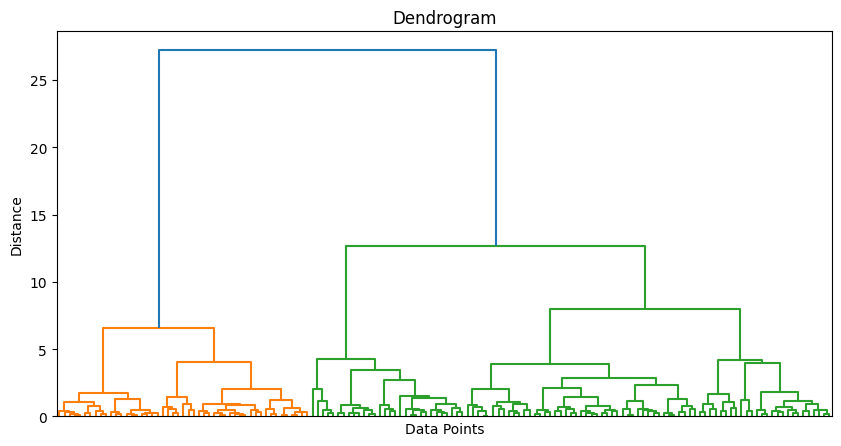

In [ ]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked, no_labels=True)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

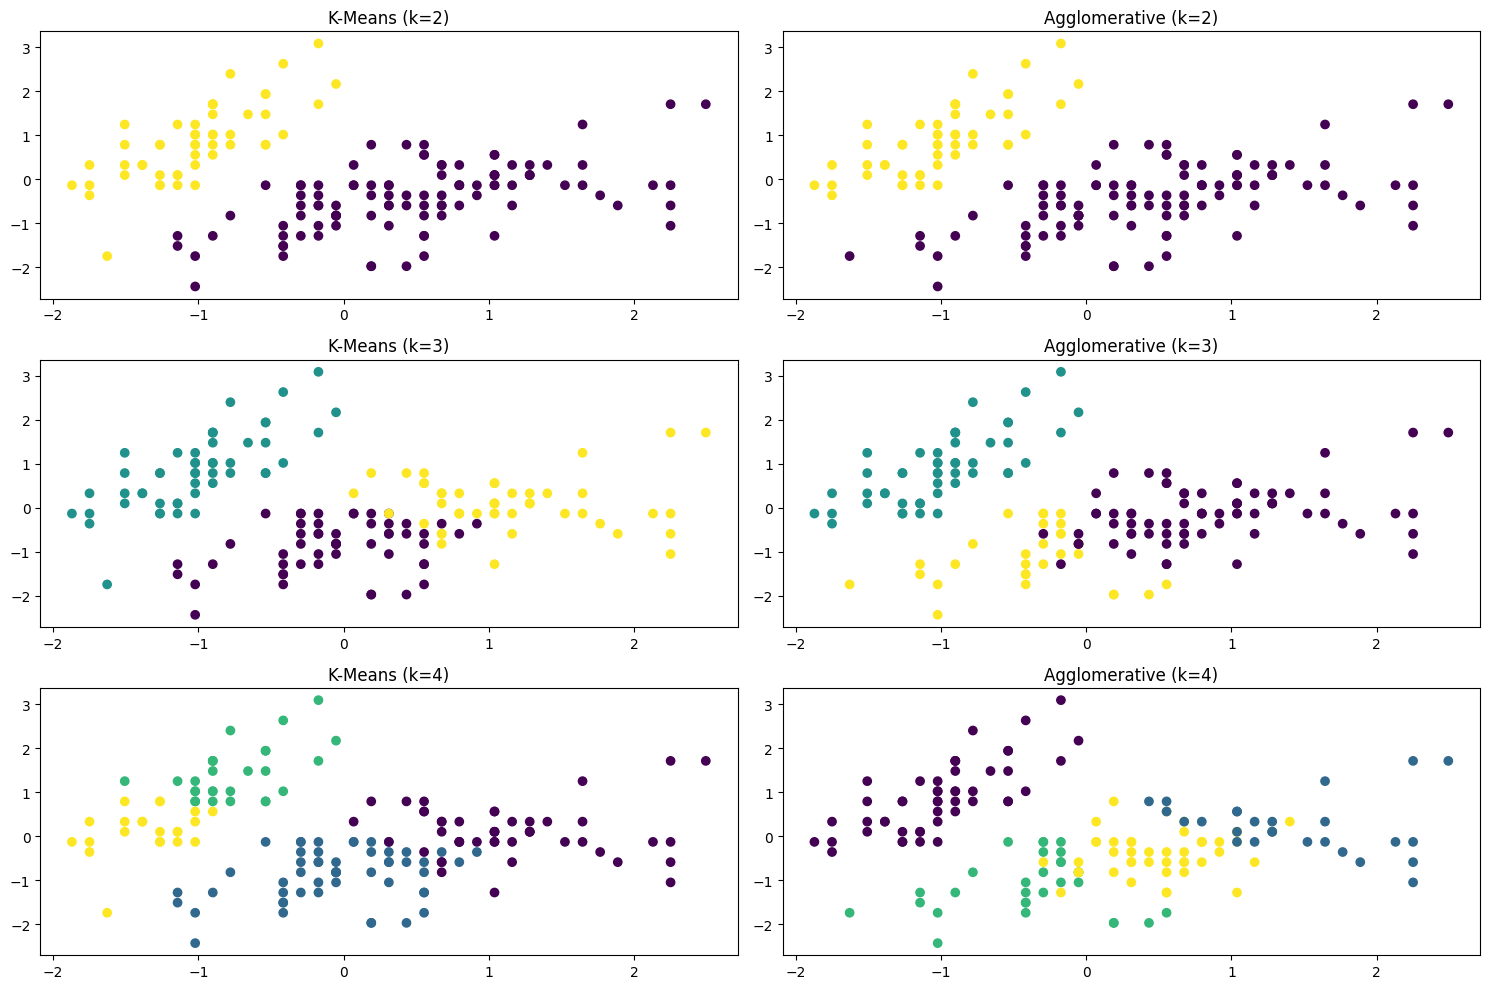

In [ ]:
plt.figure(figsize=(15,10))

for i, k in enumerate(k_values):

    # K-Means plot
    plt.subplot(3, 2, 2*i + 1)
    labels_k = kmeans_results[k][0]
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_k)
    plt.title(f"K-Means (k={k})")

    # Agglomerative plot
    plt.subplot(3, 2, 2*i + 2)
    labels_a = agglo_results[k][0]
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_a)
    plt.title(f"Agglomerative (k={k})")

plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Comparison of Silhouette Scores ---")
print("k\tK-Means\t\tAgglomerative")

for k in k_values:
    km_score = kmeans_results[k][1]
    ag_score = agglo_results[k][1]
    print(f"{k}\t{km_score:.4f}\t\t{ag_score:.4f}")


--- Comparison of Silhouette Scores ---
k	K-Means		Agglomerative
2	0.5818		0.5770
3	0.4599		0.4467
4	0.3869		0.4006


In [ ]:
'''Agglomerative performs slightly better because:
Doesn’t assume cluster shape
Builds hierarchy → better structure understanding
Dendrogram helps visualize relationships
 K-Means is better when:
Dataset is large
Need fast computation

Conclusion:
Best k = 3
Agglomerative performs slightly better because:
Captures structure better
Does not assume cluster shape
K-Means is faster and efficient for large datasets'''